In [31]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from scipy.stats import chi2_contingency
import scipy.stats as ss
import seaborn as sns
import numpy as np
import json
import glob
import os

In [32]:
ss = pd.read_csv("../../data/raw/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [33]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    data_path = "/kaggle/input/datasets/abhinavneelam/smartphone-addiction/data"
    output_path = "/kaggle/working/"
else:
    data_path = "../../data"
    output_path = "../../"

In [34]:
experiments_dir = os.path.join(output_path, "experiments")
metrics_files = glob.glob(os.path.join(experiments_dir, "*", "metrics.json"))

records = []
duration_records = []
summary_records = []

for file_path in metrics_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except:
        continue

    exp_dir = os.path.dirname(file_path)
    exp_id = os.path.basename(exp_dir)

    config_path = os.path.join(exp_dir, "oof_config.json")
    config = {}
    if os.path.exists(config_path):
        try:
            with open(config_path, 'r') as f:
                config = json.load(f)
        except:
            pass

    model = data.get('model', config.get('experiment', {}).get('model', 'unknown'))
    label = f"{model} ({exp_id})"

    fold_scores = data.get('cv', {}).get('fold_scores', [])
    for fold_idx, score in enumerate(fold_scores):
        records.append({'model_label': label, 'model_base': model,
                        'fold': fold_idx + 1, 'score': score})

    primary = data.get('primary_metric', {})
    auc = primary.get('value') if primary.get('name') == 'auc' else None
    if auc is None and fold_scores:
        auc = sum(fold_scores) / len(fold_scores)

    duration = data.get('training', {}).get('duration_seconds')
    if auc is not None and duration is not None:
        duration_records.append({'model_label': label, 'model_base': model,
                                 'auc': auc, 'duration_sec': duration})

    exp_cfg = config.get('experiment', {})
    summary_records.append({
        'model': exp_cfg.get('model', model),
        'type': exp_cfg.get('type', ''),
        'dataset_type': exp_cfg.get('dataset_type', ''),
        'description': exp_cfg.get('description', ''),
        'target': exp_cfg.get('target', ''),
        'auc': auc
    })

df_summary = pd.DataFrame(summary_records)
df_summary = df_summary.sort_values('auc', ascending=False)
df_summary

,model,type,dataset_type,description,target,auc
0,xgb,baseline,,basic xgboost baseline,,0.964006
10,xgboost,baseline,features_ohe,xgboost + ohe features,classification,0.964000
1,xgb,baseline,,basic xgboost baseline,,0.963980
15,xgboost,baseline,features,xgboost + raw features-v2,classification,0.963930
13,xgboost,baseline,features,xgboost + raw features + class balanced weights,classification,0.963660
3,lightgbm,baseline,features,basic lightgbm baseline,classification,0.963110
11,xgboost,baseline,features_ohe_imputed,xgboost + ohe features + imputation,classification,0.962940
12,xgboost,baseline,features_ohe_imputed_scaled,xgboost + ohe features + imputation + scaled,classification,0.962490
5,hgbc,baseline,features,basic hgbc baseline,classification,0.962250
2,catboost,baseline,features,basic catboost baseline,classification,0.962020


C:\Users\abhin\AppData\Local\Temp\ipykernel_20600\4043664308.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model_label', y='score', data=df, palette='Set2')


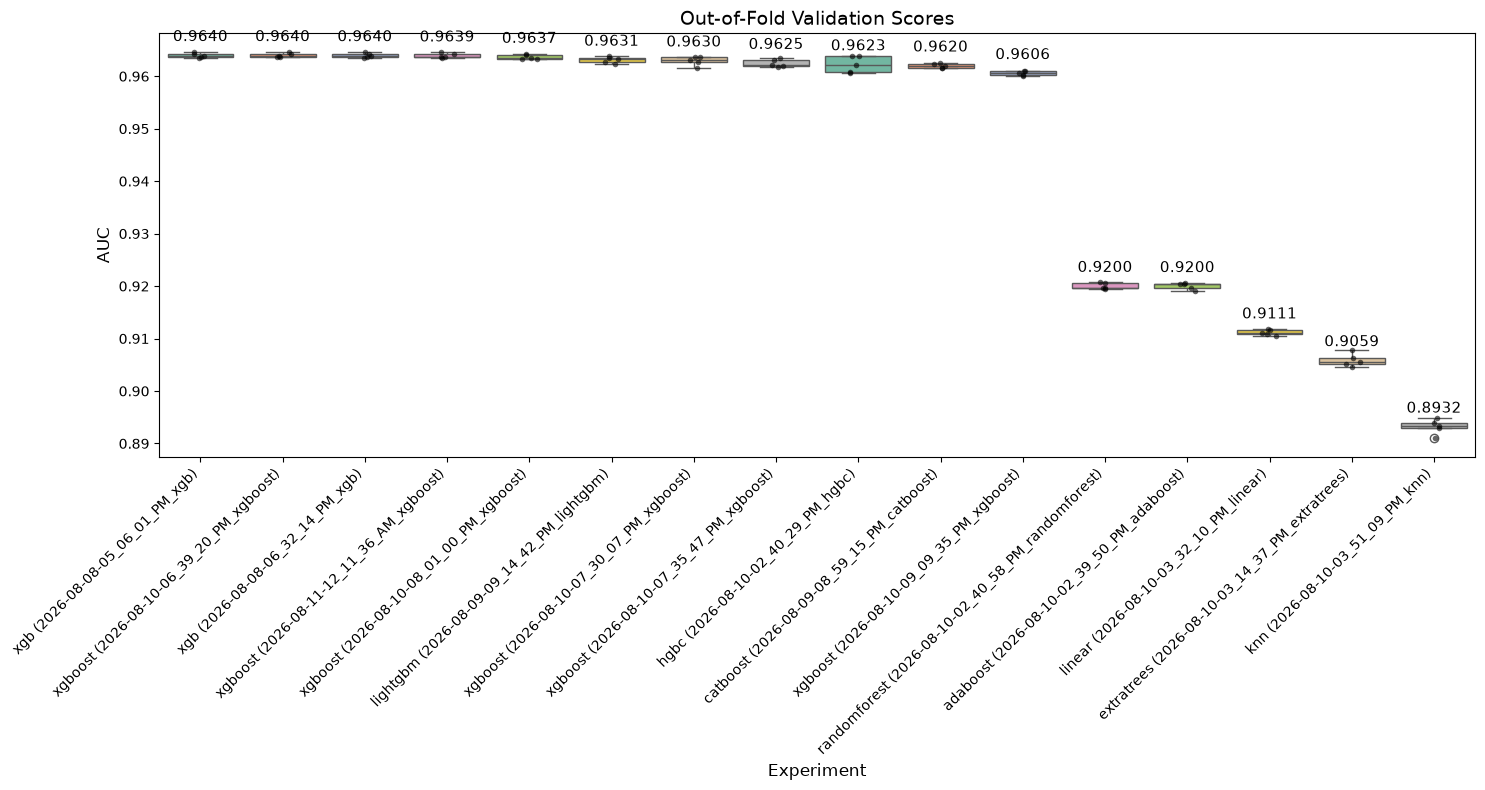

In [35]:
if records:
    df = pd.DataFrame(records)
    df['model_label'] = pd.Categorical(
        df['model_label'],
        categories=df.groupby('model_label')['score'].mean().sort_values(ascending=False).index,
        ordered=True
    )
    plt.figure(figsize=(15, 8))
    sns.boxplot(x='model_label', y='score', data=df, palette='Set2')
    sns.stripplot(x='model_label', y='score', data=df, color='black', size=4, alpha=0.6)
    means = df.groupby('model_label')['score'].mean()
    for i, label in enumerate(means.index):
        plt.text(i, means[label] + 0.002, f'{means[label]:.4f}',
                 ha='center', va='bottom', fontsize=11)
    plt.title("Out-of-Fold Validation Scores", fontsize=14)
    plt.xlabel("Experiment", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

C:\Users\abhin\AppData\Local\Temp\ipykernel_20600\385371826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_label', y='duration_min', data=df_dur, palette='Set2')


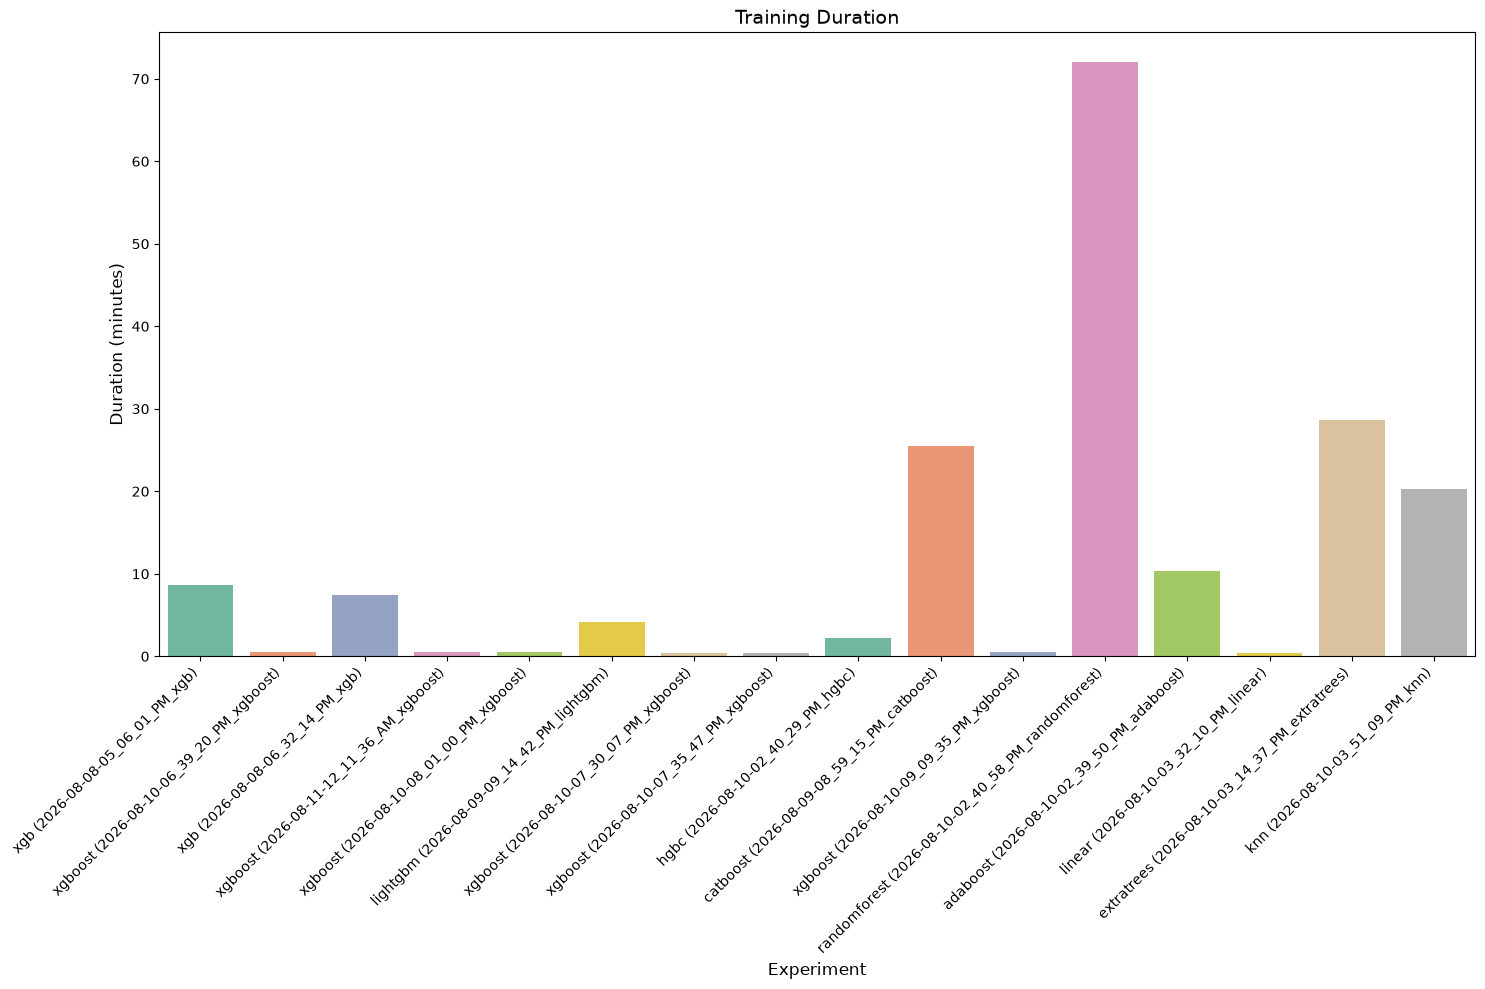

In [36]:
if duration_records:
    df_dur = pd.DataFrame(duration_records)
    df_dur = df_dur.sort_values('auc', ascending=False)
    df_dur['duration_min'] = df_dur['duration_sec'] / 60   # convert to minutes
    plt.figure(figsize=(15, 10))
    sns.barplot(x='model_label', y='duration_min', data=df_dur, palette='Set2')
    for i, row in enumerate(df_dur.itertuples()):
        plt.text(i, row.duration_min + 0.1, f"",
                 ha='center', va='bottom', fontsize=9, rotation=45)
    plt.title("Training Duration", fontsize=14)
    plt.xlabel("Experiment", fontsize=12)
    plt.ylabel("Duration (minutes)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()